In [1]:
import sys
from pathlib import Path

# 1. Encontra a raiz do projeto (uma pasta acima da pasta 'notebooks')
project_root = Path.cwd().parent

# 2. Adiciona a raiz ao sys.path do Python, se já não estiver lá
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 3. Mágicas do Jupyter para recarregar módulos automaticamente
%load_ext autoreload
%autoreload 2

# Exclui bibliotecas com extensões C que não suportam reload
%aimport -numpy
%aimport -pandas
%aimport -matplotlib
%aimport -seaborn
%aimport -scipy

print(f"Raiz do projeto configurada para: {project_root}")

Raiz do projeto configurada para: /data_lids/home/gabrielseabra/credit-score-analysis


## 1. Importações e Carregamento de Dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais do Seaborn
sns.set_theme(style="whitegrid")

# Usando o SEU loader para puxar os dados
from src.data.loader import HomeCreditDataLoader
loader = HomeCreditDataLoader(data_dir="../data")
df_train = loader.load_application_train()

df_train.head()

2026-03-10 13:55:18,165 - HomeCreditDataLoader - INFO - Carregando dados de: application_train.csv...
2026-03-10 13:55:18,300 - HomeCreditDataLoader - INFO - Sucesso! application_train.csv carregado com formato (307511, 122).


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Análise da Variável Alvo (Estatística e Probabilidade)
Em problemas de crédito, a classe de inadimplentes (TARGET = 1) costuma ser a minoria. Precisamos provar isso estatisticamente.

2026-03-10 13:55:18,409 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_68234/314082932.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='TARGET', palette='Set2')
2026-03-10 13:55:18,445 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Distribuição do TARGET:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Probabilidade Base (Taxa de Inadimplência):
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


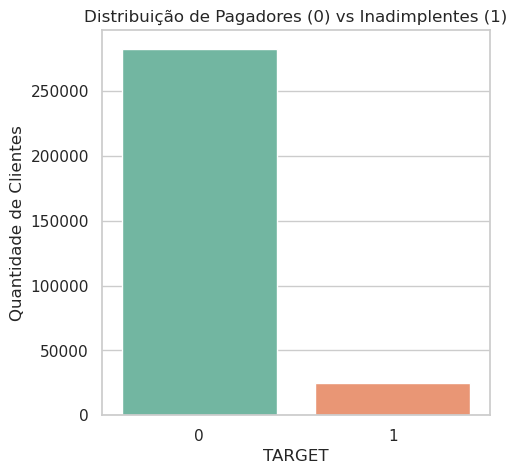

In [3]:
# Contagem e Probabilidade
target_counts = df_train['TARGET'].value_counts()
target_pct = df_train['TARGET'].value_counts(normalize=True) * 100

print("Distribuição do TARGET:")
print(target_counts)
print("\nProbabilidade Base (Taxa de Inadimplência):")
print(target_pct)

# Visualização
plt.figure(figsize=(5, 5))
sns.countplot(data=df_train, x='TARGET', palette='Set2')
plt.title('Distribuição de Pagadores (0) vs Inadimplentes (1)')
plt.ylabel('Quantidade de Clientes')
plt.show()

Estatística Descritiva da Idade (Anos):
count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: IDADE_ANOS, dtype: float64


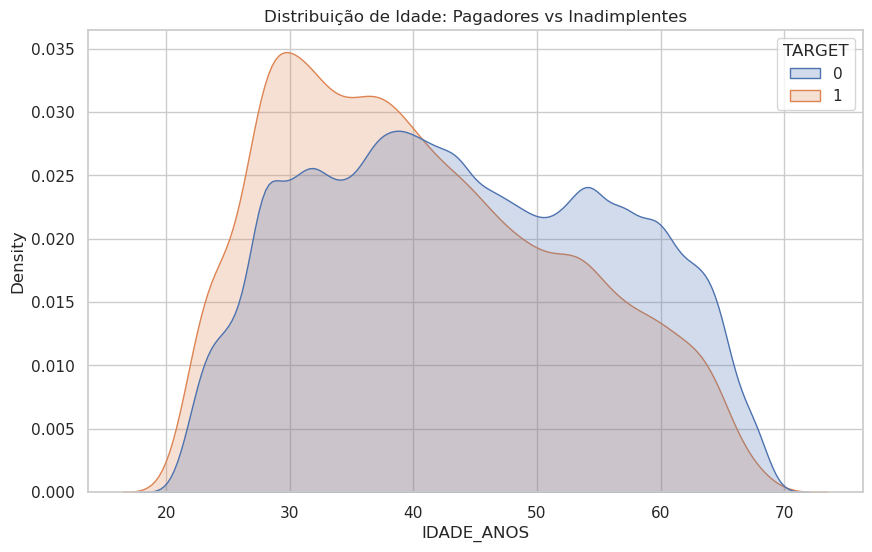

In [4]:
# Transformando Idade de dias para anos
df_train['IDADE_ANOS'] = df_train['DAYS_BIRTH'] / -365

print("Estatística Descritiva da Idade (Anos):")
print(df_train['IDADE_ANOS'].describe())

# Plotando a distribuição da Idade dividida pelo TARGET
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_train, x='IDADE_ANOS', hue='TARGET', common_norm=False, fill=True)
plt.title('Distribuição de Idade: Pagadores vs Inadimplentes')
plt.show()

In [5]:
# Convertendo dias para anos para o gráfico ficar legível
df_train['ANOS_EMPREGO'] = df_train['DAYS_EMPLOYED'] / 365
# Analisando dias de emprego
print(df_train['DAYS_EMPLOYED'].describe())

# Você notará um valor máximo absurdo de 365243 dias (1000 anos!). 
# Isso é um erro de sistema ou valor preenchido artificialmente.
anomalias = df_train[df_train['DAYS_EMPLOYED'] == 365243]
print(f"\nClientes com anomalia em DAYS_EMPLOYED: {len(anomalias)}")

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Clientes com anomalia em DAYS_EMPLOYED: 55374


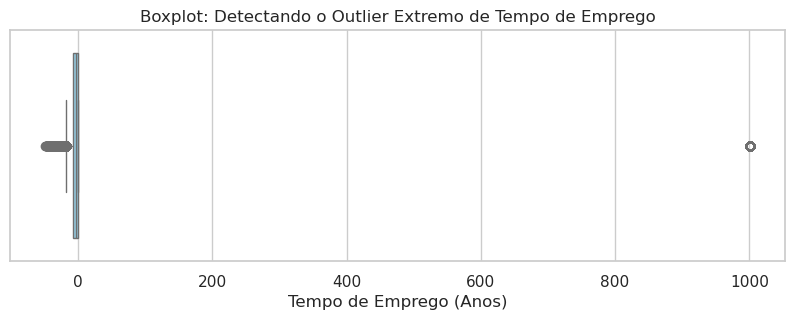

In [6]:
# Convertendo dias para anos para o gráfico ficar legível
df_train['ANOS_EMPREGO'] = df_train['DAYS_EMPLOYED'] / 365
plt.figure(figsize=(10, 3))
# Orientação horizontal (x) é melhor para ler valores altos
sns.boxplot(x=df_train['ANOS_EMPREGO'], color='skyblue')
plt.title('Boxplot: Detectando o Outlier Extremo de Tempo de Emprego')
plt.xlabel('Tempo de Emprego (Anos)')
plt.show()

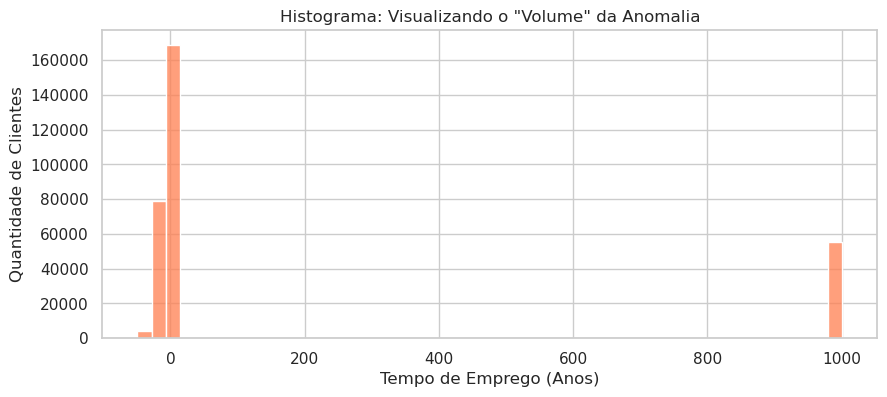

In [7]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df_train, x='ANOS_EMPREGO', bins=50, color='coral')
plt.title('Histograma: Visualizando o "Volume" da Anomalia')
plt.xlabel('Tempo de Emprego (Anos)')
plt.ylabel('Quantidade de Clientes')
plt.show()

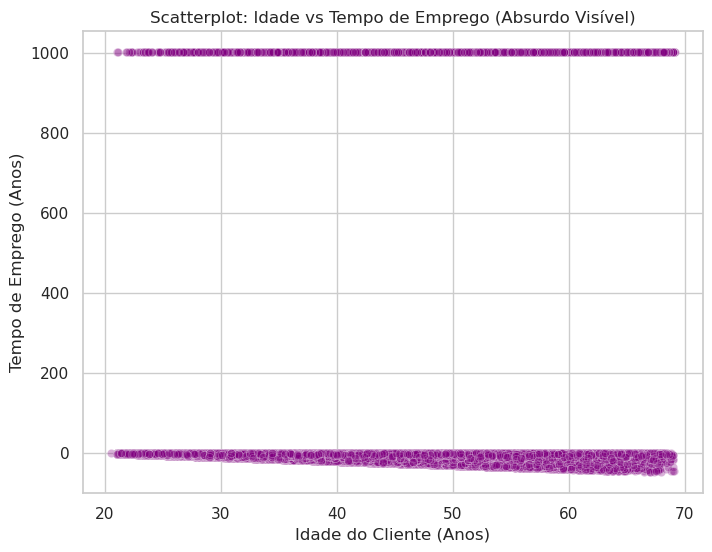

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_train, 
    x='IDADE_ANOS', 
    y='ANOS_EMPREGO', 
    alpha=0.3, # Transparência para ver onde há acúmulo de pontos
    color='purple'
)
plt.title('Scatterplot: Idade vs Tempo de Emprego (Absurdo Visível)')
plt.xlabel('Idade do Cliente (Anos)')
plt.ylabel('Tempo de Emprego (Anos)')
plt.show()

## 3. Qualidade dos Dados

Antes de modelar, precisamos entender o que está faltando e o que está mal tipado. Colunas com muitos nulos podem ser descartadas ou imputadas; tipos errados causam erros silenciosos.

### 3.1 Valores Nulos

In [9]:
# Tabela de nulos: contagem e percentual, apenas colunas com pelo menos 1 nulo
nulos = pd.DataFrame({
    'nulos': df_train.isnull().sum(),
    'pct (%)': (df_train.isnull().mean() * 100).round(2)
})
nulos = nulos[nulos['nulos'] > 0].sort_values('pct (%)', ascending=False)

print(f"Colunas com valores nulos: {len(nulos)} de {df_train.shape[1]}")
print(f"Colunas com >50% de nulos: {(nulos['pct (%)'] > 50).sum()}")
print()
print(nulos.to_string())

Colunas com valores nulos: 67 de 124
Colunas com >50% de nulos: 41

                               nulos  pct (%)
COMMONAREA_MEDI               214865    69.87
COMMONAREA_MODE               214865    69.87
COMMONAREA_AVG                214865    69.87
NONLIVINGAPARTMENTS_MODE      213514    69.43
NONLIVINGAPARTMENTS_MEDI      213514    69.43
NONLIVINGAPARTMENTS_AVG       213514    69.43
FONDKAPREMONT_MODE            210295    68.39
LIVINGAPARTMENTS_AVG          210199    68.35
LIVINGAPARTMENTS_MEDI         210199    68.35
LIVINGAPARTMENTS_MODE         210199    68.35
FLOORSMIN_MEDI                208642    67.85
FLOORSMIN_MODE                208642    67.85
FLOORSMIN_AVG                 208642    67.85
YEARS_BUILD_MODE              204488    66.50
YEARS_BUILD_MEDI              204488    66.50
YEARS_BUILD_AVG               204488    66.50
OWN_CAR_AGE                   202929    65.99
LANDAREA_AVG                  182590    59.38
LANDAREA_MEDI                 182590    59.38
LANDAREA_MOD

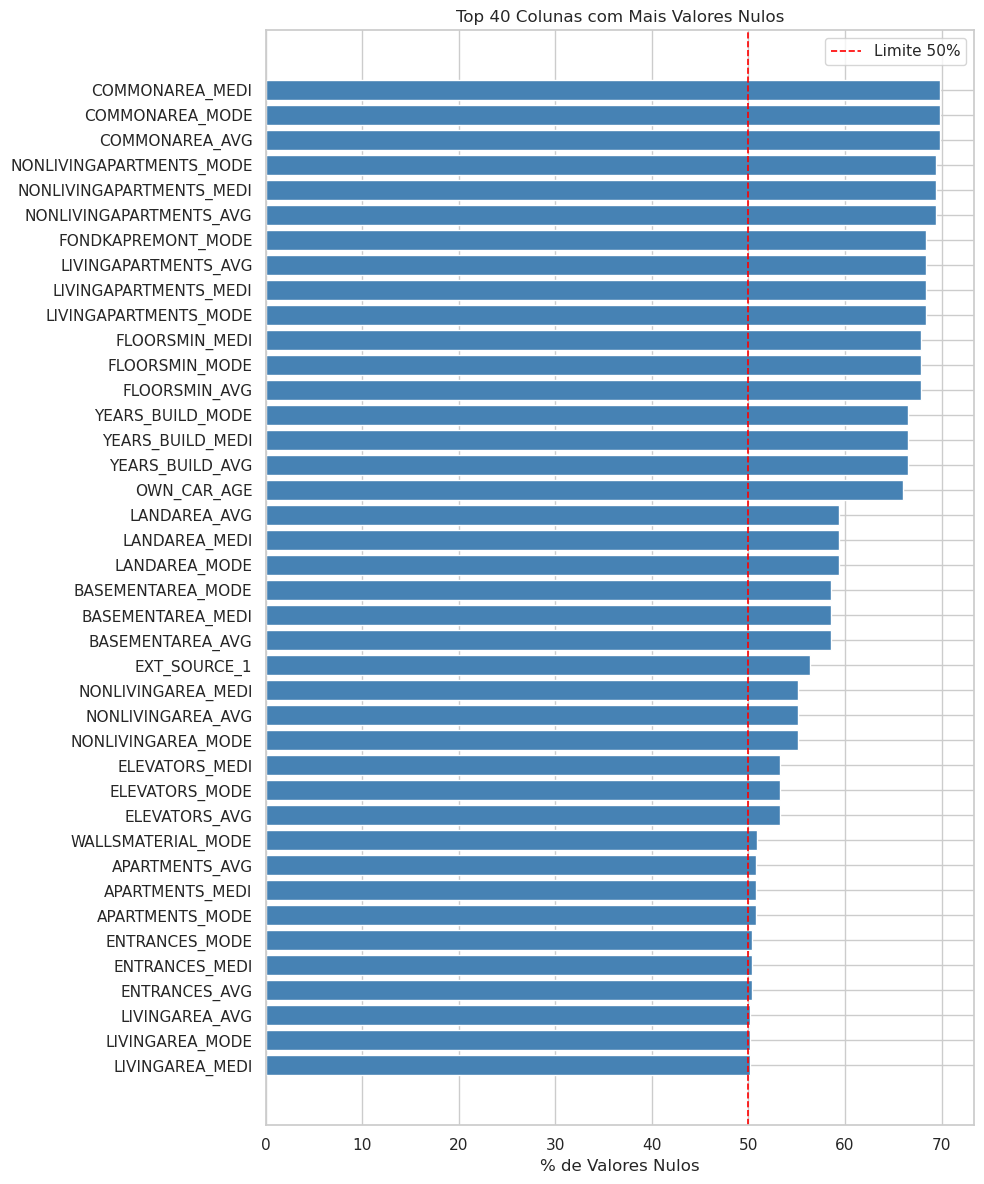

In [10]:
# Barplot horizontal: % de nulos por coluna (top 40)
top_nulos = nulos.head(40)

plt.figure(figsize=(10, 12))
bars = plt.barh(top_nulos.index[::-1], top_nulos['pct (%)'][::-1], color='steelblue')
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.2, label='Limite 50%')
plt.xlabel('% de Valores Nulos')
plt.title('Top 40 Colunas com Mais Valores Nulos')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 Tipos de Dados

In [11]:
# Contagem de colunas por tipo de dado
tipos = df_train.dtypes.value_counts().rename_axis('dtype').reset_index(name='qtd_colunas')
print("Distribuição de tipos de dados:")
print(tipos.to_string(index=False))

# Colunas categóricas (object): verificar cardinalidade
cols_object = df_train.select_dtypes('object').columns
print(f"\nColunas categóricas ({len(cols_object)}):")
cardinalidade = df_train[cols_object].nunique().sort_values(ascending=False)
print(cardinalidade.to_string())

Distribuição de tipos de dados:
  dtype  qtd_colunas
float64           67
  int64           41
    str           16

Colunas categóricas (16):
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2


/tmp/ipykernel_68234/3871718624.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_object = df_train.select_dtypes('object').columns


### 3.3 Linhas Duplicadas

In [12]:
duplicadas = df_train.duplicated().sum()
ids_duplicados = df_train['SK_ID_CURR'].duplicated().sum()

print(f"Linhas completamente duplicadas : {duplicadas}")
print(f"SK_ID_CURR duplicados (chave)   : {ids_duplicados}")

if duplicadas == 0 and ids_duplicados == 0:
    print("\nSem duplicatas — cada linha é um cliente único.")

Linhas completamente duplicadas : 0
SK_ID_CURR duplicados (chave)   : 0

Sem duplicatas — cada linha é um cliente único.


## 4. Variáveis Numéricas vs TARGET

Comparar a distribuição de variáveis numéricas entre pagadores (TARGET=0) e inadimplentes (TARGET=1) revela quais features têm poder discriminativo.

### 4.1 Renda, Crédito e Anuidade

In [13]:
# Mediana de variáveis financeiras por TARGET
vars_financeiras = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

print("Mediana por TARGET (0=Pagador, 1=Inadimplente):")
print(df_train.groupby('TARGET')[vars_financeiras].median().T.rename(columns={0: 'Pagador', 1: 'Inadimplente'}))

Mediana por TARGET (0=Pagador, 1=Inadimplente):
TARGET             Pagador  Inadimplente
AMT_INCOME_TOTAL  148500.0      135000.0
AMT_CREDIT        517788.0      497520.0
AMT_ANNUITY        24876.0       25263.0
AMT_GOODS_PRICE   450000.0      450000.0


2026-03-10 13:55:20,868 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-10 13:55:20,908 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-10 13:55:21,324 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-10 13:55:21,362 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-10 13:55:21,

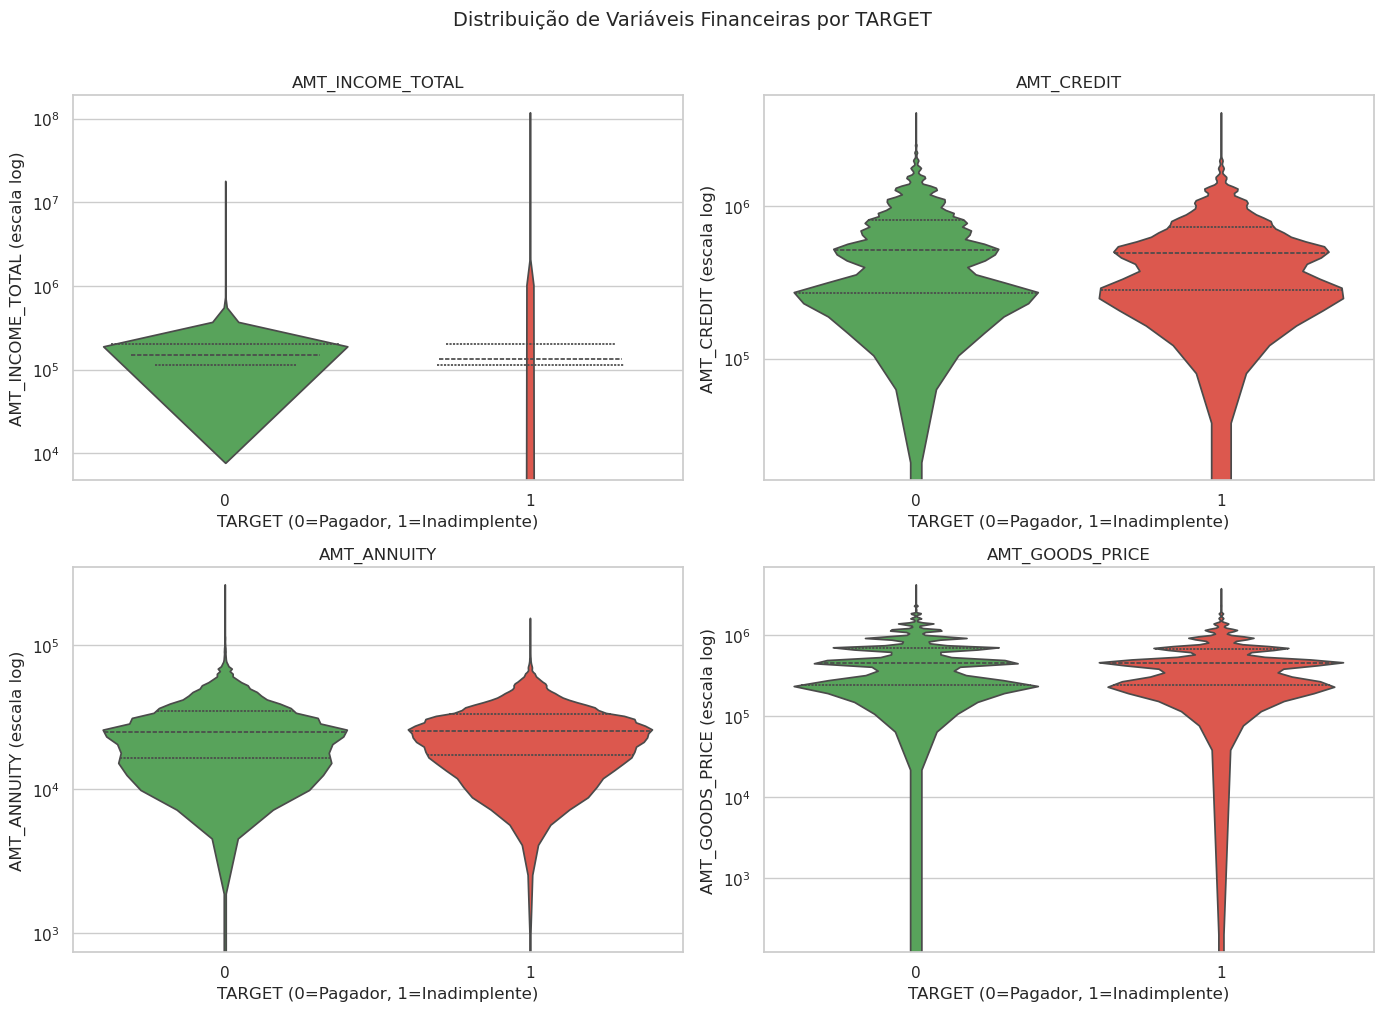

In [14]:
# Violin plots: distribuição completa de cada variável por TARGET
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(vars_financeiras):
    sns.violinplot(
        data=df_train, x='TARGET', y=col,
        hue='TARGET',
        palette={0: '#4CAF50', 1: '#F44336'},
        inner='quartile', legend=False, ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('TARGET (0=Pagador, 1=Inadimplente)')
    axes[i].set_yscale('log')
    axes[i].set_ylabel(f'{col} (escala log)')

plt.suptitle('Distribuição de Variáveis Financeiras por TARGET', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Razão Crédito / Renda

Uma razão alta indica que o cliente está tomando um crédito desproporcional à sua renda — sinal clássico de risco.

Mediana da razão crédito/renda por TARGET:
TARGET
Pagador         3.266653
Inadimplente    3.253143
Name: RAZAO_CREDITO_RENDA, dtype: float64


/tmp/ipykernel_68234/2983743931.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=taxa_inadimplencia.index, y=taxa_inadimplencia.values, palette='Reds', ax=axes[1])


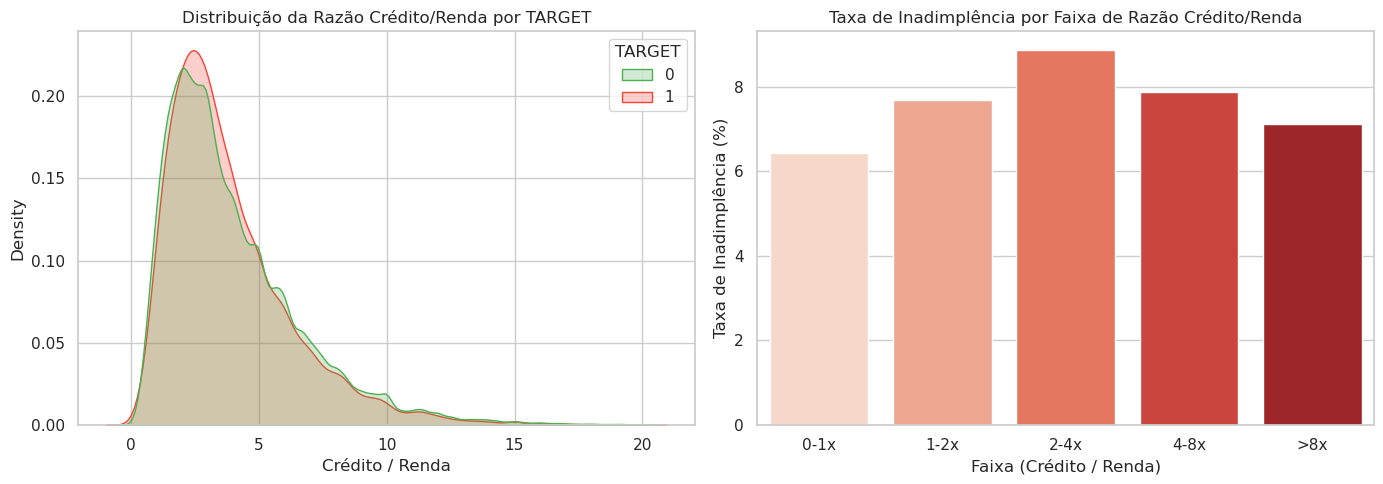

In [15]:
df_train['RAZAO_CREDITO_RENDA'] = df_train['AMT_CREDIT'] / df_train['AMT_INCOME_TOTAL']

print("Mediana da razão crédito/renda por TARGET:")
print(df_train.groupby('TARGET')['RAZAO_CREDITO_RENDA'].median().rename({0: 'Pagador', 1: 'Inadimplente'}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE por TARGET
sns.kdeplot(
    data=df_train[df_train['RAZAO_CREDITO_RENDA'] < 20],  # remove extremos para visualização
    x='RAZAO_CREDITO_RENDA', hue='TARGET',
    common_norm=False, fill=True,
    palette={0: '#4CAF50', 1: '#F44336'},
    ax=axes[0]
)
axes[0].set_title('Distribuição da Razão Crédito/Renda por TARGET')
axes[0].set_xlabel('Crédito / Renda')

# Taxa de inadimplência por faixa da razão
df_train['FAIXA_RAZAO'] = pd.cut(df_train['RAZAO_CREDITO_RENDA'], bins=[0, 1, 2, 4, 8, 100], labels=['0-1x', '1-2x', '2-4x', '4-8x', '>8x'])
taxa_inadimplencia = df_train.groupby('FAIXA_RAZAO', observed=True)['TARGET'].mean() * 100

sns.barplot(x=taxa_inadimplencia.index, y=taxa_inadimplencia.values, palette='Reds', ax=axes[1])
axes[1].set_title('Taxa de Inadimplência por Faixa de Razão Crédito/Renda')
axes[1].set_xlabel('Faixa (Crédito / Renda)')
axes[1].set_ylabel('Taxa de Inadimplência (%)')

plt.tight_layout()
plt.show()

### 4.3 EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3

Scores externos de bureau de crédito. Costumam ser as variáveis mais preditivas do dataset — valores mais altos indicam menor risco.

Mediana dos scores externos por TARGET:
TARGET         Pagador  Inadimplente
EXT_SOURCE_1  0.517452      0.361675
EXT_SOURCE_2  0.573905      0.440381
EXT_SOURCE_3  0.546023      0.379100


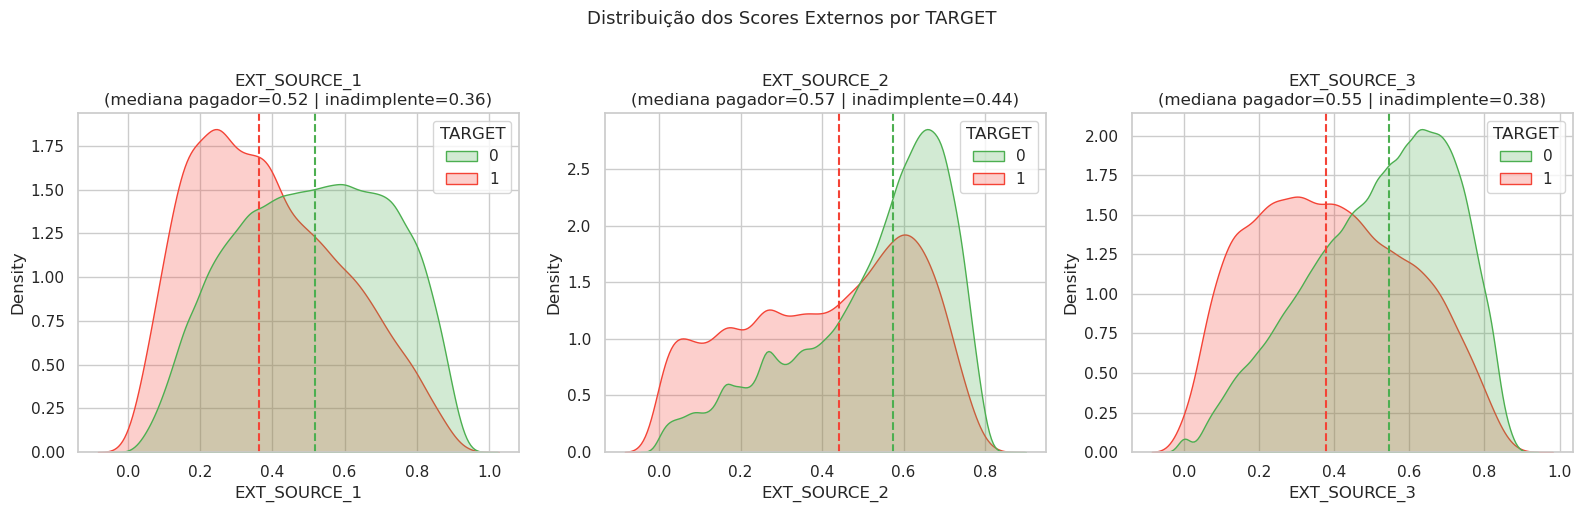

In [16]:
ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print("Mediana dos scores externos por TARGET:")
print(df_train.groupby('TARGET')[ext_sources].median().T.rename(columns={0: 'Pagador', 1: 'Inadimplente'}))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(ext_sources):
    sns.kdeplot(
        data=df_train.dropna(subset=[col]),
        x=col, hue='TARGET',
        common_norm=False, fill=True,
        palette={0: '#4CAF50', 1: '#F44336'},
        ax=axes[i]
    )
    mediana_0 = df_train.loc[df_train['TARGET'] == 0, col].median()
    mediana_1 = df_train.loc[df_train['TARGET'] == 1, col].median()
    axes[i].axvline(mediana_0, color='#4CAF50', linestyle='--', linewidth=1.5)
    axes[i].axvline(mediana_1, color='#F44336', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'{col}\n(mediana pagador={mediana_0:.2f} | inadimplente={mediana_1:.2f})')
    axes[i].set_xlabel(col)

plt.suptitle('Distribuição dos Scores Externos por TARGET', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Correlação de Variáveis Numéricas com TARGET

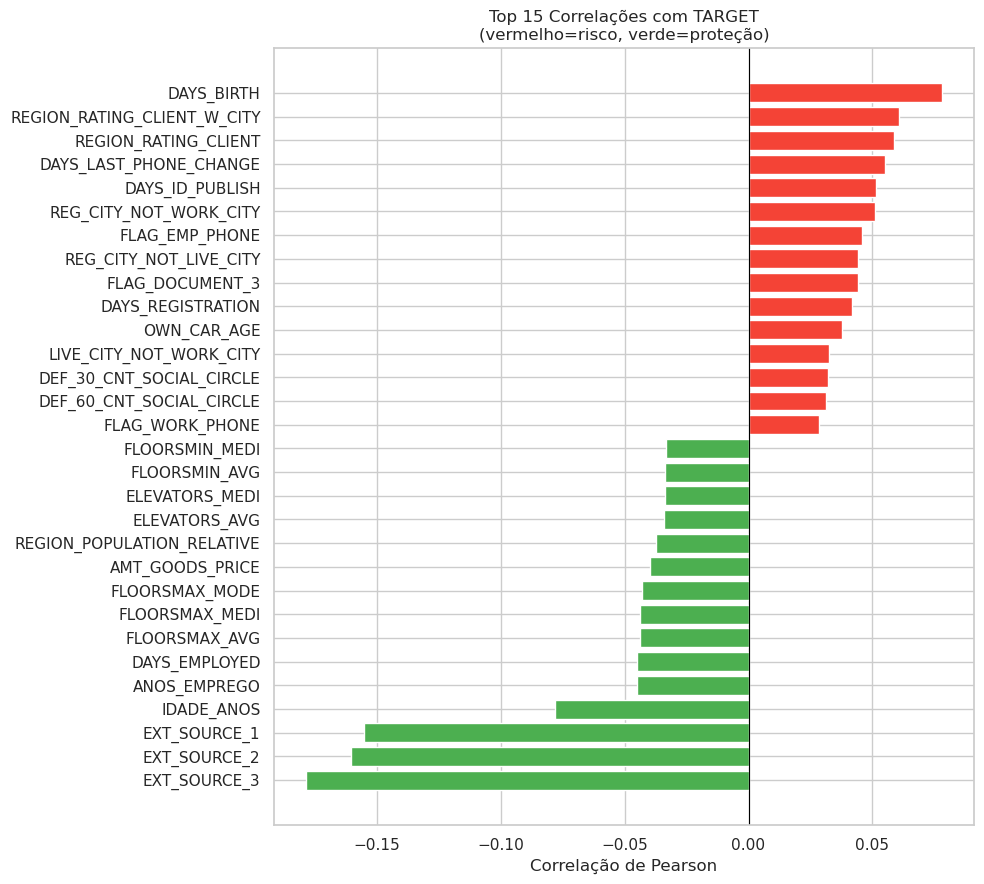

In [17]:
# Correlação de Pearson de todas as colunas numéricas com TARGET
corr_target = (
    df_train.select_dtypes('number')
    .corr()['TARGET']
    .drop('TARGET')
    .dropna()
    .sort_values()
)

# Top 15 correlações positivas e negativas
top_corr = pd.concat([corr_target.head(15), corr_target.tail(15)])

cores = ['#F44336' if v > 0 else '#4CAF50' for v in top_corr.values]

plt.figure(figsize=(10, 9))
plt.barh(top_corr.index, top_corr.values, color=cores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Correlações com TARGET\n(vermelho=risco, verde=proteção)')
plt.xlabel('Correlação de Pearson')
plt.tight_layout()
plt.show()

## 5. Variáveis Categóricas vs TARGET

Para variáveis categóricas, a métrica mais direta é a **taxa de inadimplência por categoria** — o percentual de clientes com TARGET=1 dentro de cada grupo.

In [18]:
def plot_taxa_inadimplencia(df, col, ax, title=None):
    """Barplot horizontal com taxa de inadimplência e contagem por categoria."""
    taxa = df.groupby(col)['TARGET'].agg(['mean', 'count']).reset_index()
    taxa['mean'] *= 100
    taxa = taxa.sort_values('mean', ascending=True)

    bars = ax.barh(taxa[col], taxa['mean'], color='#E57373')
    ax.axvline(df['TARGET'].mean() * 100, color='black', linestyle='--',
               linewidth=1.2, label=f'Média geral ({df["TARGET"].mean()*100:.1f}%)')
    ax.set_xlabel('Taxa de Inadimplência (%)')
    ax.set_title(title or col)
    ax.legend(fontsize=8)

    # Rótulo: % e n
    for bar, (_, row) in zip(bars, taxa.iterrows()):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                f"{row['mean']:.1f}%  (n={row['count']:,})",
                va='center', fontsize=8)

### 5.1 Tipo de Contrato e Gênero

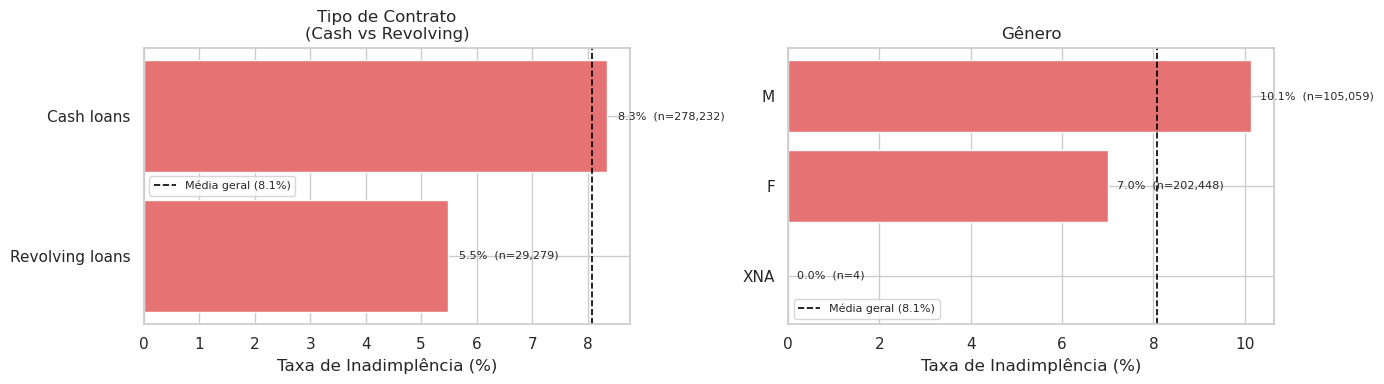

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_taxa_inadimplencia(df_train, 'NAME_CONTRACT_TYPE', axes[0],
                        title='Tipo de Contrato\n(Cash vs Revolving)')
plot_taxa_inadimplencia(df_train, 'CODE_GENDER', axes[1],
                        title='Gênero')

plt.tight_layout()
plt.show()

### 5.2 Escolaridade e Tipo de Renda

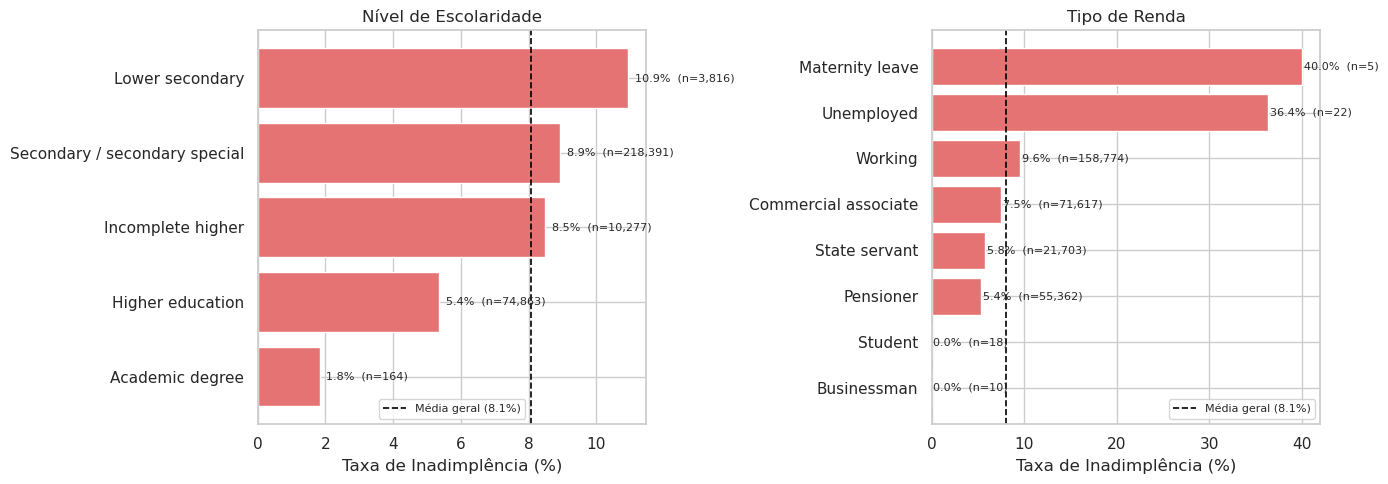

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_taxa_inadimplencia(df_train, 'NAME_EDUCATION_TYPE', axes[0],
                        title='Nível de Escolaridade')
plot_taxa_inadimplencia(df_train, 'NAME_INCOME_TYPE', axes[1],
                        title='Tipo de Renda')

plt.tight_layout()
plt.show()

### 5.3 Profissão e Setor de Trabalho

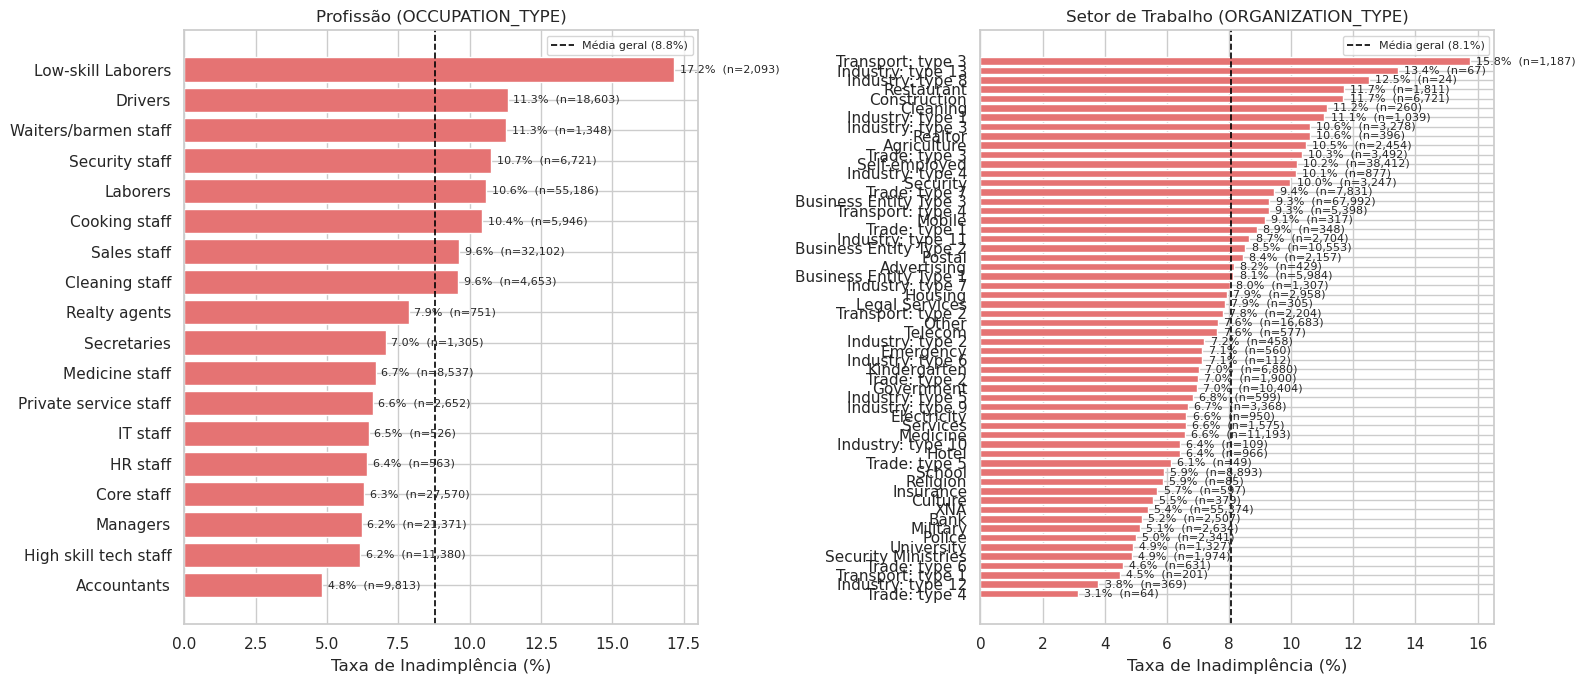

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_taxa_inadimplencia(df_train.dropna(subset=['OCCUPATION_TYPE']),
                        'OCCUPATION_TYPE', axes[0], title='Profissão (OCCUPATION_TYPE)')
plot_taxa_inadimplencia(df_train, 'ORGANIZATION_TYPE', axes[1],
                        title='Setor de Trabalho (ORGANIZATION_TYPE)')

plt.tight_layout()
plt.show()

## 6. Correlações

Três métricas complementares:
- **Pearson / Point-biserial**: correlação linear entre variável contínua e TARGET binário
- **Cramer's V**: associação entre duas variáveis categóricas (varia de 0 a 1)
- **Heatmap**: visão geral das correlações entre as principais variáveis numéricas

### 6.1 Heatmap de Correlação entre Variáveis Numéricas

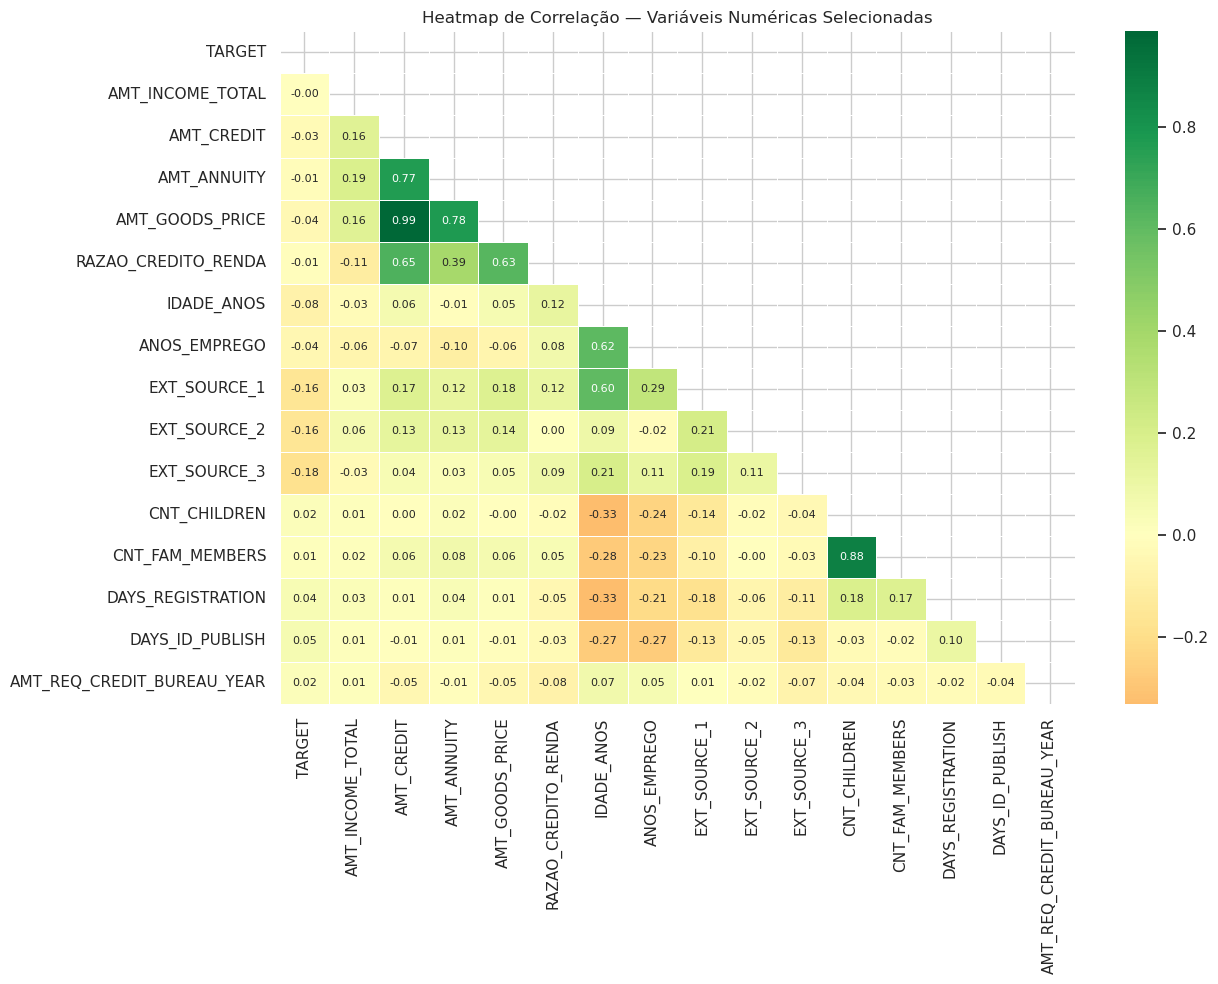

In [22]:
# Seleciona variáveis numéricas de interesse (exclui flags binárias e IDs)
cols_heatmap = [
    'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'RAZAO_CREDITO_RENDA', 'IDADE_ANOS', 'ANOS_EMPREGO',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

corr_matrix = df_train[cols_heatmap].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # oculta triângulo superior
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Heatmap de Correlação — Variáveis Numéricas Selecionadas')
plt.tight_layout()
plt.show()

### 6.2 Point-Biserial: Variáveis Contínuas vs TARGET

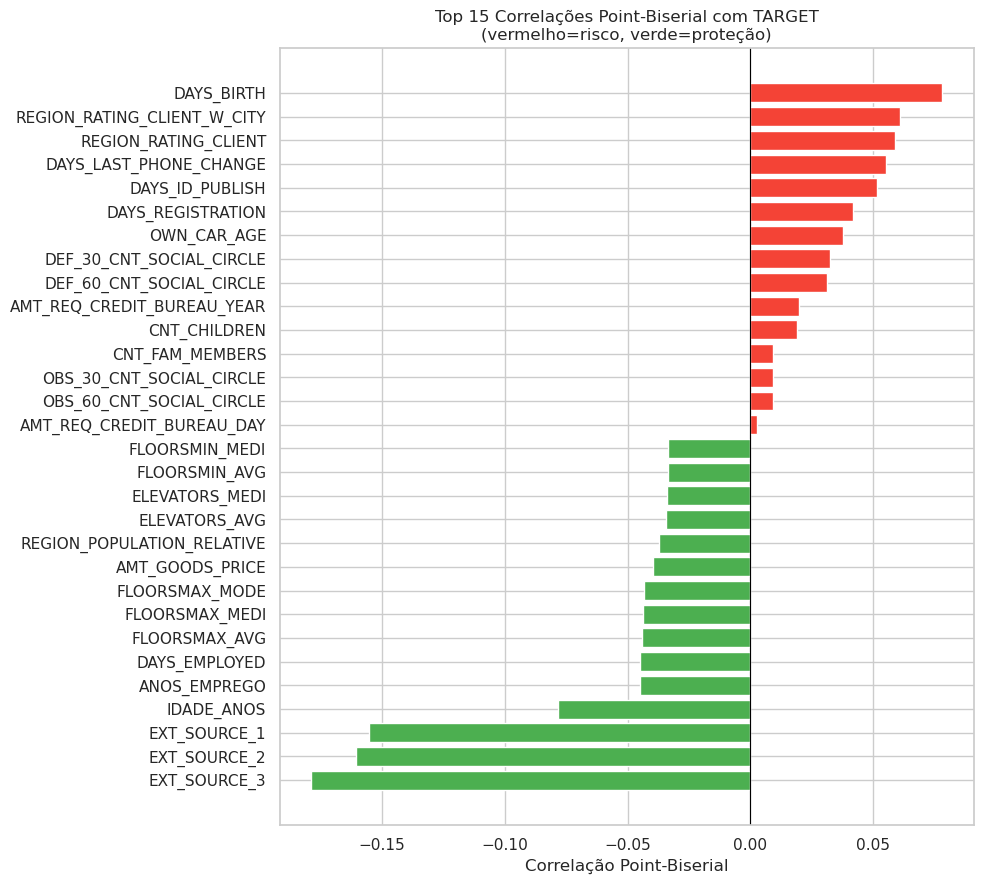


Variáveis com correlação significativa (p<0.05): 68 de 76


In [23]:
from scipy.stats import pointbiserialr

cols_numericas = df_train.select_dtypes('number').columns.drop('TARGET')

resultados_pb = []
for col in cols_numericas:
    validos = df_train[['TARGET', col]].dropna()
    if validos[col].nunique() > 2:  # ignora flags binárias
        corr, pval = pointbiserialr(validos['TARGET'], validos[col])
        resultados_pb.append({'coluna': col, 'correlacao': corr, 'p_valor': pval})

df_pb = (
    pd.DataFrame(resultados_pb)
    .sort_values('correlacao')
    .assign(significativo=lambda d: d['p_valor'] < 0.05)
)

# Top 15 de cada extremo
top_pb = pd.concat([df_pb.head(15), df_pb.tail(15)])

cores_pb = ['#F44336' if v > 0 else '#4CAF50' for v in top_pb['correlacao']]

plt.figure(figsize=(10, 9))
plt.barh(top_pb['coluna'], top_pb['correlacao'], color=cores_pb)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Correlações Point-Biserial com TARGET\n(vermelho=risco, verde=proteção)')
plt.xlabel('Correlação Point-Biserial')
plt.tight_layout()
plt.show()

print(f"\nVariáveis com correlação significativa (p<0.05): {df_pb['significativo'].sum()} de {len(df_pb)}")

### 6.3 Cramer's V: Associação entre Variáveis Categóricas e TARGET

/tmp/ipykernel_68234/3865571750.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = df_train.select_dtypes('object').columns


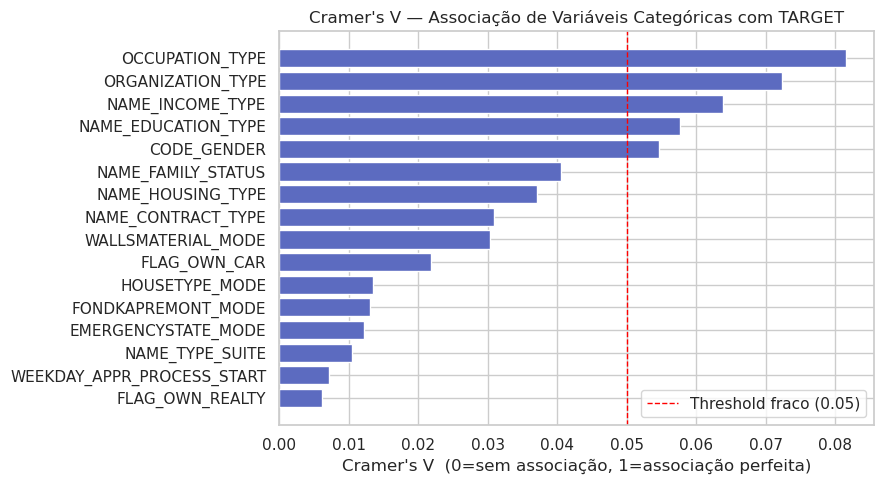

                    coluna  cramer_v
           OCCUPATION_TYPE    0.0815
         ORGANIZATION_TYPE    0.0723
          NAME_INCOME_TYPE    0.0638
       NAME_EDUCATION_TYPE    0.0576
               CODE_GENDER    0.0547
        NAME_FAMILY_STATUS    0.0405
         NAME_HOUSING_TYPE    0.0370
        NAME_CONTRACT_TYPE    0.0309
        WALLSMATERIAL_MODE    0.0303
              FLAG_OWN_CAR    0.0218
            HOUSETYPE_MODE    0.0134
        FONDKAPREMONT_MODE    0.0131
       EMERGENCYSTATE_MODE    0.0121
           NAME_TYPE_SUITE    0.0104
WEEKDAY_APPR_PROCESS_START    0.0071
           FLAG_OWN_REALTY    0.0061


In [24]:
from scipy.stats import chi2_contingency

def cramers_v(col_a, col_b):
    """Calcula o Cramer's V entre duas variáveis categóricas."""
    tabela = pd.crosstab(col_a, col_b)
    chi2, _, _, _ = chi2_contingency(tabela)
    n = tabela.sum().sum()
    k = min(tabela.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0.0

cols_cat = df_train.select_dtypes('object').columns

resultados_cv = []
for col in cols_cat:
    validos = df_train[['TARGET', col]].dropna()
    v = cramers_v(validos[col], validos['TARGET'])
    resultados_cv.append({'coluna': col, "cramer_v": round(v, 4)})

df_cv = pd.DataFrame(resultados_cv).sort_values('cramer_v', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(df_cv['coluna'], df_cv['cramer_v'], color='#5C6BC0')
plt.axvline(0.05, color='red', linestyle='--', linewidth=1, label='Threshold fraco (0.05)')
plt.xlabel("Cramer's V  (0=sem associação, 1=associação perfeita)")
plt.title("Cramer's V — Associação de Variáveis Categóricas com TARGET")
plt.legend()
plt.tight_layout()
plt.show()

print(df_cv.sort_values('cramer_v', ascending=False).to_string(index=False))